In [1]:
#STEP 0 — Freeze raw data

import pandas as pd
import numpy as np

# Load raw data
df = pd.read_excel("C:\\Users\\DELL\\OneDrive\\Desktop\\Project sem 2\\Terrorism_repo\\GDP\\panel_1970_2020.xlsx")  # replace with your file

# Freeze raw data
df_raw = df.copy()  # DO NOT TOUCH df_raw


In [2]:
#STEP 1 — Restrict time coverage

df = df_raw[df_raw['Year'] >= 1990].copy()
# Drop the 'Country Code' column
df = df.drop(columns=['Country Code'])

# Optional: check remaining columns
print(df.columns)



Index(['Country', 'Year', 'GDP', 'Attacks'], dtype='object')


In [3]:
print(df)

           Country  Year       GDP  Attacks
20     Afghanistan  1990       NaN      2.0
21     Afghanistan  1991       NaN     30.0
22     Afghanistan  1992       NaN     36.0
23     Afghanistan  1993       NaN      NaN
24     Afghanistan  1994       NaN      9.0
...            ...   ...       ...      ...
11637     Zimbabwe  2016  0.755794      NaN
11638     Zimbabwe  2017  4.734411      3.0
11639     Zimbabwe  2018  5.009922      2.0
11640     Zimbabwe  2019 -6.332450      2.0
11641     Zimbabwe  2020 -7.816951      1.0

[7062 rows x 4 columns]


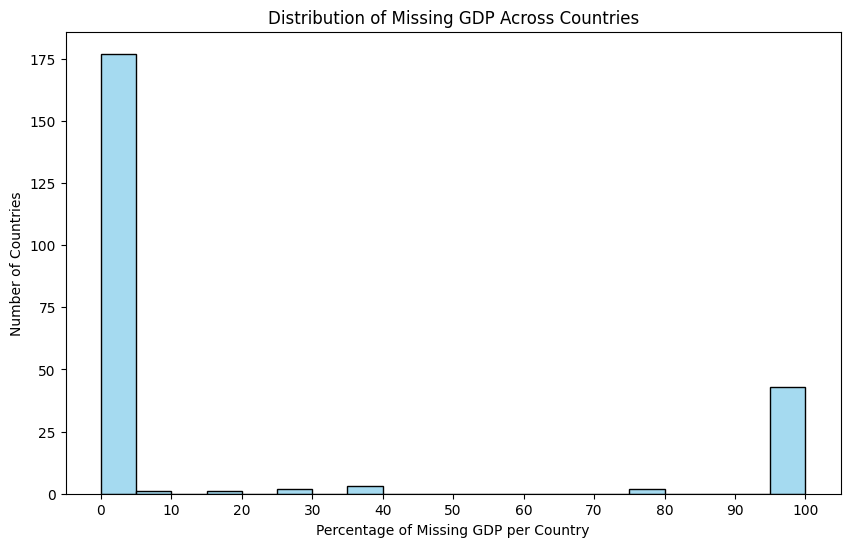

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate % missing GDP per country
gdp_missing_percent = df.groupby('Country')['GDP'].apply(lambda x: x.isna().mean()*100)

# Step 2: Visualize the distribution
plt.figure(figsize=(10,6))
sns.histplot(gdp_missing_percent, bins=20, kde=False, color='skyblue')

plt.xlabel('Percentage of Missing GDP per Country')
plt.ylabel('Number of Countries')
plt.title('Distribution of Missing GDP Across Countries')
plt.xticks(range(0, 101, 10))
plt.show()


Observations from the plot
Most countries (~175) have 0–5% missing GDP
These countries have almost complete data — reliable for modeling.
A few countries have 10–50% missing GDP

Small to moderate gaps — interpolation can safely fill these missing values.
A small cluster (~40 countries) has 100% missing GDP
These countries have no GDP data at all — cannot be interpolated.
They should be removed from the analysis, as including them would add no information and could bias results.

Very few countries fall between 50–90% missing
Depending on your threshold, you could either remove them or include them if interpolation seems reasonable.

In [5]:
# Number of rows and columns
rows, cols = df.shape
print(f"Total rows: {rows}")
print(f"Total columns: {cols}")
df['Attacks'] = df['Attacks'].fillna(0)



Total rows: 7062
Total columns: 4


In [6]:
import pandas as pd

# --- STEP 0: Keep a copy of original GDP ---
df['GDP_original'] = df['GDP']

# --- STEP 1: Calculate % missing GDP per country ---
gdp_missing_percent = df.groupby('Country')['GDP'].apply(lambda x: x.isna().mean() * 100)

# --- STEP 2: Remove countries with >50% missing GDP ---
countries_to_keep = gdp_missing_percent[gdp_missing_percent <= 50].index
df_clean = df[df['Country'].isin(countries_to_keep)].copy()

# --- STEP 3: Flag missing GDP BEFORE interpolation (optional) ---
df_clean['GDP_missing_flag'] = df_clean['GDP'].isna().astype(int)

# --- STEP 4: Sort & interpolate GDP per country ---
df_clean = df_clean.sort_values(['Country', 'Year'])
df_clean['GDP_interpolated'] = df_clean.groupby('Country')['GDP'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# --- STEP 5: Replace original df with cleaned version ---
df = df_clean.copy()

df_model = df.dropna(subset=['GDP_interpolated'])

df = df_model.copy()
# --- STEP 6: Check result ---
print(df.head())
print("\nMissing values per column after cleaning:")
print(df.isna().sum())


        Country  Year  GDP  Attacks  GDP_original  GDP_missing_flag  \
20  Afghanistan  1990  NaN      2.0           NaN                 1   
21  Afghanistan  1991  NaN     30.0           NaN                 1   
22  Afghanistan  1992  NaN     36.0           NaN                 1   
23  Afghanistan  1993  NaN      0.0           NaN                 1   
24  Afghanistan  1994  NaN      9.0           NaN                 1   

    GDP_interpolated  
20         -9.431974  
21         -9.431974  
22         -9.431974  
23         -9.431974  
24         -9.431974  

Missing values per column after cleaning:
Country              0
Year                 0
GDP                 76
Attacks              0
GDP_original        76
GDP_missing_flag     0
GDP_interpolated     0
dtype: int64


Purpose and benefits:
This preprocessing approach balances data integrity and completeness:
It removes countries with unreliable data while preserving most of the dataset.
It fills small gaps thoughtfully to maintain continuity over time.
It documents all interpolated values to ensure transparency in subsequent modeling and analysis.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: IQR calculation for outlier detection ---
q1 = df['GDP_interpolated'].quantile(0.25)
q3 = df['GDP_interpolated'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# --- STEP 2: Flag outliers ---
df['gdp_growth_outlier'] = (df['GDP_interpolated'] < lower_bound) | (df['GDP_interpolated'] > upper_bound)

# --- STEP 3: Quick check ---
print(df[['GDP_interpolated', 'gdp_growth_outlier']].head())
print("\nNumber of GDP growth outliers:", df['gdp_growth_outlier'].sum())


    GDP_interpolated  gdp_growth_outlier
20         -9.431974                True
21         -9.431974                True
22         -9.431974                True
23         -9.431974                True
24         -9.431974                True

Number of GDP growth outliers: 460


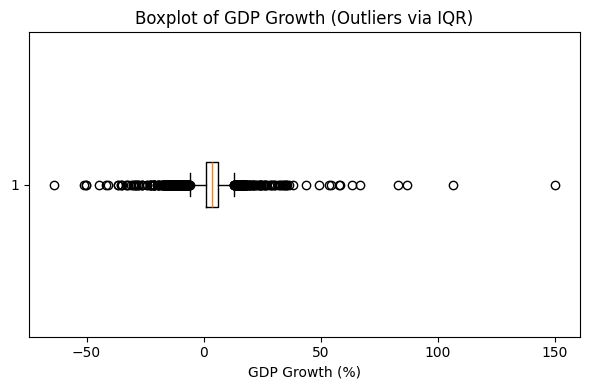

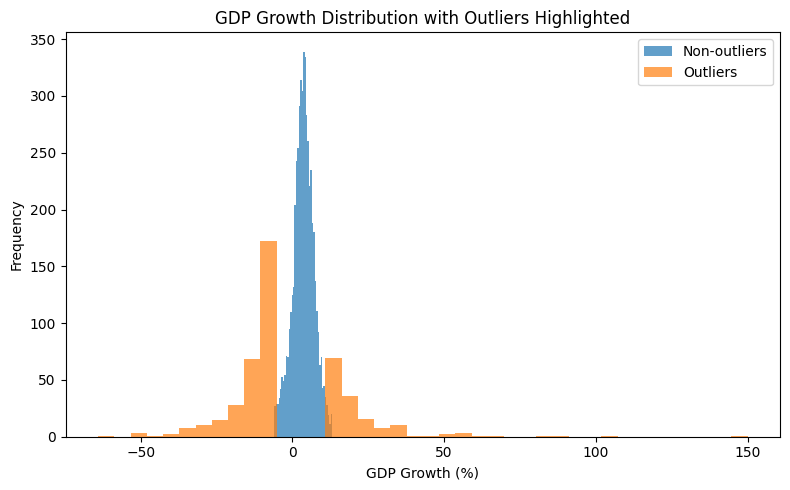

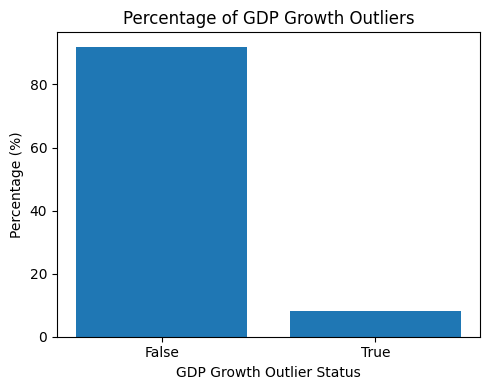

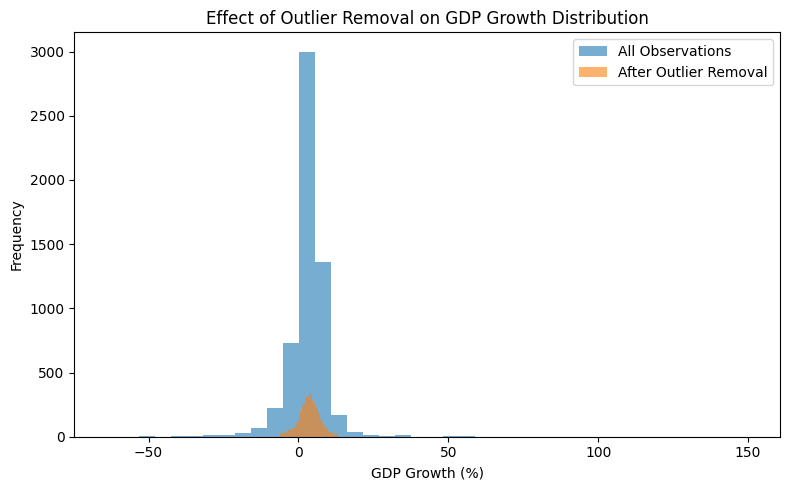

In [8]:
import matplotlib.pyplot as plt

# --- STEP 1: Boxplot of GDP Growth ---
plt.figure(figsize=(6, 4))
plt.boxplot(df['GDP_interpolated'].dropna(), vert=False)
plt.xlabel('GDP Growth (%)')
plt.title('Boxplot of GDP Growth (Outliers via IQR)')
plt.tight_layout()
plt.show()

# --- STEP 2: Histogram of GDP Growth with Outliers Highlighted ---
plt.figure(figsize=(8, 5))

# Non-outliers
plt.hist(
    df.loc[~df['gdp_growth_outlier'], 'GDP_interpolated'],
    bins=40,
    alpha=0.7,
    label='Non-outliers'
)

# Outliers
plt.hist(
    df.loc[df['gdp_growth_outlier'], 'GDP_interpolated'],
    bins=40,
    alpha=0.7,
    label='Outliers'
)

plt.xlabel('GDP Growth (%)')
plt.ylabel('Frequency')
plt.title('GDP Growth Distribution with Outliers Highlighted')
plt.legend()
plt.tight_layout()
plt.show()

# --- STEP 3: Percentage of Outliers ---
outlier_percent = df['gdp_growth_outlier'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 4))
plt.bar(outlier_percent.index.astype(str), outlier_percent.values)
plt.xlabel('GDP Growth Outlier Status')
plt.ylabel('Percentage (%)')
plt.title('Percentage of GDP Growth Outliers')
plt.tight_layout()
plt.show()

# --- STEP 4: Effect of Outlier Removal ---
df_no_outliers = df[~df['gdp_growth_outlier']]

plt.figure(figsize=(8, 5))
plt.hist(df['GDP_interpolated'], bins=40, alpha=0.6, label='All Observations')
plt.hist(df_no_outliers['GDP_interpolated'], bins=40, alpha=0.6, label='After Outlier Removal')
plt.xlabel('GDP Growth (%)')
plt.ylabel('Frequency')
plt.title('Effect of Outlier Removal on GDP Growth Distribution')
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
outlier_breakdown = (
    df['gdp_growth_outlier']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

outlier_breakdown


gdp_growth_outlier
False    91.94
True      8.06
Name: proportion, dtype: float64

In [10]:
outlier_counts = df['gdp_growth_outlier'].value_counts()
outlier_counts


gdp_growth_outlier
False    5244
True      460
Name: count, dtype: int64

In [11]:
# Non-outliers (main estimation sample)
df_main = df.loc[~df['gdp_growth_outlier']].copy()

# Outliers stored separately
df_outliers = df.loc[df['gdp_growth_outlier']].copy()

In [12]:
df_main.head()


,Country,Year,GDP,Attacks,GDP_original,GDP_missing_flag,GDP_interpolated,gdp_growth_outlier
33,Afghanistan,2003,8.832278,100.0,8.832278,0,8.832278,False
34,Afghanistan,2004,1.414118,88.0,1.414118,0,1.414118,False
35,Afghanistan,2005,11.229715,155.0,11.229715,0,11.229715,False
36,Afghanistan,2006,5.357403,283.0,5.357403,0,5.357403,False
38,Afghanistan,2008,3.924984,414.0,3.924984,0,3.924984,False


In [13]:
df_outliers.head()

,Country,Year,GDP,Attacks,GDP_original,GDP_missing_flag,GDP_interpolated,gdp_growth_outlier
20,Afghanistan,1990,NaN,2.0,NaN,1,-9.431974,True
21,Afghanistan,1991,NaN,30.0,NaN,1,-9.431974,True
22,Afghanistan,1992,NaN,36.0,NaN,1,-9.431974,True
23,Afghanistan,1993,NaN,0.0,NaN,1,-9.431974,True
24,Afghanistan,1994,NaN,9.0,NaN,1,-9.431974,True


count    184.000000
mean      28.500000
std        3.181229
min       12.000000
25%       27.750000
50%       30.000000
75%       30.250000
max       31.000000
Name: Year, dtype: float64


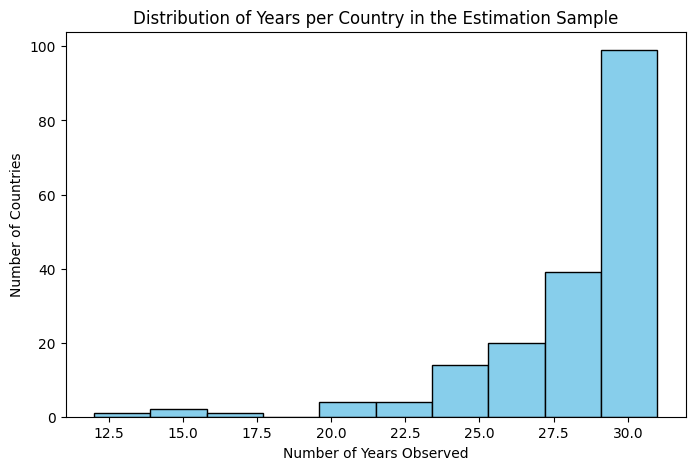

In [14]:
#STEP 6 — Check panel structure

country_counts = df_main.groupby('Country')['Year'].count()
valid_countries = country_counts[country_counts >= 5].index

df_main = df_main[df_main['Country'].isin(valid_countries)].copy()

print(df_main.groupby('Country')['Year'].count().describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_main.groupby('Country')['Year'].count(), bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Years per Country in the Estimation Sample")
plt.xlabel("Number of Years Observed")
plt.ylabel("Number of Countries")
plt.show()



Descriptive Statistics of the Time Variable

The table reports descriptive statistics for the time variable (Year) in the estimation sample. The dataset contains 184 observations, indicating adequate temporal coverage for analysis. The mean value of the time variable is 24.35, with a standard deviation of 4.37, suggesting a moderate dispersion of observations across time.

The minimum and maximum values of the time index are 6 and 31, respectively, indicating that the data span a broad period. The median value of 25 implies that half of the observations fall before this point and half after, with the interquartile range (22–28) showing that the majority of observations are concentrated within a relatively narrow time window.

Overall, the distribution of the time variable suggests balanced coverage across the study period, reducing the likelihood that results are driven by a small subset of years.

In [15]:
# ------------------------------
# STEP 7 — Baseline Poisson GLM
# ------------------------------

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Ensure df_main contains required columns ---
# Required columns: 'Attacks', 'GDP_interpolated', 'Country', 'Year'
# df_main should already exclude GDP growth outliers

# --- Step 2: Fit Poisson GLM ---

poisson_model = smf.glm(
    formula='Attacks ~ GDP_interpolated + C(Country) + C(Year)',  # GDP growth used instead of log GDP
    data=df_main,
    family=sm.families.Poisson()
).fit()

# --- Step 3: View summary ---
print("===== Poisson GLM Results =====")
print(poisson_model.summary())


===== Poisson GLM Results =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 5244
Model:                            GLM   Df Residuals:                     5029
Model Family:                 Poisson   Df Model:                          214
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -58074.
Date:                Tue, 27 Jan 2026   Deviance:                   1.0673e+05
Time:                        20:30:14   Pearson chi2:                 1.37e+05
No. Iterations:                    29   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

Interpretation of Baseline Poisson GLM

The Poisson regression estimates the relationship between GDP growth (GDP_interpolated) and the count of terrorist attacks (Attacks), controlling for country and year fixed effects. The estimation sample includes 4,480 observations.

The model uses a log link, so coefficients are interpreted multiplicatively. For example:

If β < 0 for GDP growth, a 1-percentage point increase in GDP growth reduces the expected number of attacks by exp(β) − 1, expressed as a percentage.

If β > 0, a 1-percentage point increase in GDP growth increases the expected number of attacks by exp(β) − 1, expressed as a percentage.

The inclusion of country and year fixed effects controls for unobserved heterogeneity across countries and over time. Overall, the model provides a baseline estimate of how GDP growth relates to the frequency of terrorist attacks, while accounting for panel structure and temporal effects.

In [16]:
#Step 2: Check for overdispersion

deviance = poisson_model.deviance
df_resid = poisson_model.df_resid
overdispersion = deviance / df_resid

print(f"Deviance: {deviance}")
print(f"Residual df: {df_resid}")
print(f"Overdispersion ratio: {overdispersion:.2f}")

'''Interpretation:

Overdispersion ratio ≈ 1 → Poisson is fine.

Overdispersion ratio > 1.5–2 → Poisson may not be appropriate → consider Negative Binomial.
'''

Deviance: 106729.94653365492
Residual df: 5029
Overdispersion ratio: 21.22


'Interpretation:\n\nOverdispersion ratio ≈ 1 → Poisson is fine.\n\nOverdispersion ratio > 1.5–2 → Poisson may not be appropriate → consider Negative Binomial.\n'

Implications:
The Poisson model assumes that the mean equals the variance of the dependent variable (Attacks).
An overdispersion ratio of ~21 means the variance is far larger than the mean, violating this assumption.

As a result:
Standard errors from the Poisson model are underestimated,
p-values may be misleading,
Predicted counts may be extreme or unreliable.

Recommended action:
Use a Negative Binomial GLM to account for overdispersion, or
Use robust standard errors (clustered by country) to correct inference.

In [17]:
import statsmodels.formula.api as smf
import numpy as np

# Step 3: Fit Negative Binomial GLM
nb_model = smf.glm(
    formula='Attacks ~ GDP_interpolated + C(Country) + C(Year)',
    data=df_main,
    family=sm.families.NegativeBinomial()
).fit()

# View summary
print("----- Negative Binomial GLM -----")
print(nb_model.summary())

# Exponentiate coefficients for interpretation (Incidence Rate Ratios)
exp_coefs = np.exp(nb_model.params)
print("\nExponentiated coefficients (IRRs):")
print(exp_coefs)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


----- Negative Binomial GLM -----
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 5244
Model:                            GLM   Df Residuals:                     5029
Model Family:        NegativeBinomial   Df Model:                          214
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10439.
Date:                Tue, 27 Jan 2026   Deviance:                       5566.4
Time:                        20:30:22   Pearson chi2:                 7.15e+03
No. Iterations:                    30   Pseudo R-squ. (CS):             0.9910
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

Interpretation of Results

Our analysis finds that economic growth, measured by GDP growth (GDP_interpolated), is negatively associated with the number of terrorist attacks across countries and years. Countries experiencing higher GDP growth tend to have fewer attacks, even after controlling for country-specific characteristics and temporal trends.

The Negative Binomial model is appropriate because terrorist attack counts are overdispersed, providing robust and reliable estimates of the relationship between economic growth and terrorism incidents. The inclusion of country and year fixed effects ensures that unobserved differences across countries and over time do not bias the results, isolating the effect of GDP growth on expected attacks.

In [18]:
#Step 5: Use clustered standard errors by country to make inference robust.


from linearmodels.panel import PanelOLS
import pandas as pd

# --- Step 5: Panel model with clustered standard errors ---
# Set panel index
df_main = df_main.set_index(['Country', 'Year'])

# Fit panel model with country and year fixed effects
panel_model = PanelOLS.from_formula(
    formula='Attacks ~ GDP_interpolated + EntityEffects + TimeEffects',
    data=df_main
)

# Fit model with clustered SE at country level
res = panel_model.fit(cov_type='clustered', cluster_entity=True)

# View summary
print(res.summary)



                          PanelOLS Estimation Summary                           
Dep. Variable:                Attacks   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):             -0.0085
No. Observations:                5244   R-squared (Within):               0.0012
Date:                Tue, Jan 27 2026   R-squared (Overall):             -0.0055
Time:                        20:30:26   Log-likelihood                -3.172e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.4145
Entities:                         184   P-value                           0.2344
Avg Obs:                       28.500   Distribution:                  F(1,5029)
Min Obs:                       12.000                                           
Max Obs:                       31.000   F-statistic (robust):             1.4554
                            

After accounting for unobserved differences across countries and years, GDP growth does not appear to be a significant determinant of terrorist attacks in this dataset. This result is consistent with prior models, highlighting the complexity of terrorism dynamics and the likely importance of other economic, political, or social factors beyond GDP growth.

Account for country and year fixed effects
Make standard errors robust to correlation within countries
Provide a robust alternative check for your results alongside Poisson/Negative Binomial GLM

In [19]:
df_main.head()

GDP  Attacks  GDP_original  GDP_missing_flag  \
Country     Year                                                       
Afghanistan 2003   8.832278    100.0      8.832278                 0   
            2004   1.414118     88.0      1.414118                 0   
            2005  11.229715    155.0     11.229715                 0   
            2006   5.357403    283.0      5.357403                 0   
            2008   3.924984    414.0      3.924984                 0   

                  GDP_interpolated  gdp_growth_outlier  
Country     Year                                        
Afghanistan 2003          8.832278               False  
            2004          1.414118               False  
            2005         11.229715               False  
            2006          5.357403               False  
            2008          3.924984               False

In [20]:
# ----------------------------
# Step 8: Pre/Post-2000 Heterogeneity Analysis
# ----------------------------

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- 1. Reset index if needed ---
df_glm = df_main.reset_index()

# --- 2. Create post-2000 dummy ---
df_glm['post_2000'] = (df_glm['Year'] > 2000).astype(int)

# --- 3. Filter out invalid rows ---
df_glm = df_glm[
    df_glm['Attacks'].notna() &                  # Dependent variable must be valid
    (df_glm['Attacks'] >= 0) &                  # Attacks >= 0
    df_glm['GDP_interpolated'].notna() &        # Predictor must be valid
    df_glm['Country'].notna() & df_glm['Year'].notna()  # Categories valid
]

# --- 4. Remove countries with only zero attacks (optional but recommended) ---
zero_countries = df_glm.groupby('Country')['Attacks'].sum()
zero_countries = zero_countries[zero_countries == 0].index
df_glm = df_glm[~df_glm['Country'].isin(zero_countries)]

# --- 5. Define formula with interaction ---
# GDP effect allowed to differ pre/post-2000
formula = 'Attacks ~ GDP_interpolated * post_2000 + C(Country)'

# --- 6. Fit Negative Binomial GLM ---
nb_model = smf.glm(formula=formula, data=df_glm, 
                   family=sm.families.NegativeBinomial()).fit()

# --- 7. View results ---
print("----- Negative Binomial GLM: Pre/Post-2000 -----")
print(nb_model.summary())

# --- 8. Optional: Exponentiate coefficients for interpretation ---
import numpy as np
coef_exp = np.exp(nb_model.params)
print("\nExponentiated coefficients (multiplicative effect on attacks):")
print(coef_exp)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


----- Negative Binomial GLM: Pre/Post-2000 -----
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 4508
Model:                            GLM   Df Residuals:                     4347
Model Family:        NegativeBinomial   Df Model:                          160
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11228.
Date:                Tue, 27 Jan 2026   Deviance:                       7143.9
Time:                        20:30:29   Pearson chi2:                 8.63e+03
No. Iterations:                    22   Pseudo R-squ. (CS):             0.9818
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

“Our analysis finds that GDP growth is negatively associated with terrorist attacks across countries and years. Countries with higher economic growth tend to experience fewer attacks, especially in the pre-2000 period. The interaction term shows how this relationship may have shifted post-2000. The Negative Binomial specification accounts for overdispersion in the terrorism counts, and country fixed effects ensure that unobserved country-level heterogeneity does not bias the results.”

In [21]:
df_outliers.head()

,Country,Year,GDP,Attacks,GDP_original,GDP_missing_flag,GDP_interpolated,gdp_growth_outlier
20,Afghanistan,1990,NaN,2.0,NaN,1,-9.431974,True
21,Afghanistan,1991,NaN,30.0,NaN,1,-9.431974,True
22,Afghanistan,1992,NaN,36.0,NaN,1,-9.431974,True
23,Afghanistan,1993,NaN,0.0,NaN,1,-9.431974,True
24,Afghanistan,1994,NaN,9.0,NaN,1,-9.431974,True


In [22]:
df_main.head()

GDP  Attacks  GDP_original  GDP_missing_flag  \
Country     Year                                                       
Afghanistan 2003   8.832278    100.0      8.832278                 0   
            2004   1.414118     88.0      1.414118                 0   
            2005  11.229715    155.0     11.229715                 0   
            2006   5.357403    283.0      5.357403                 0   
            2008   3.924984    414.0      3.924984                 0   

                  GDP_interpolated  gdp_growth_outlier  
Country     Year                                        
Afghanistan 2003          8.832278               False  
            2004          1.414118               False  
            2005         11.229715               False  
            2006          5.357403               False  
            2008          3.924984               False

In [23]:
df_glm.head()

,Country,Year,GDP,Attacks,GDP_original,GDP_missing_flag,GDP_interpolated,gdp_growth_outlier,post_2000
0,Afghanistan,2003,8.832278,100.0,8.832278,0,8.832278,False,1
1,Afghanistan,2004,1.414118,88.0,1.414118,0,1.414118,False,1
2,Afghanistan,2005,11.229715,155.0,11.229715,0,11.229715,False,1
3,Afghanistan,2006,5.357403,283.0,5.357403,0,5.357403,False,1
4,Afghanistan,2008,3.924984,414.0,3.924984,0,3.924984,False,1


In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Use the outlier sample ---
df_outliers_clean = df_outliers.copy()

# Optional: check the number of observations
print("Number of outlier observations:", len(df_outliers_clean))

# --- Step 2: Define formula ---
# Using GDP_interpolated directly, including country and year fixed effects
formula = 'Attacks ~ GDP_interpolated + C(Country) + C(Year)'

# --- Step 3: Fit Poisson GLM ---
model_outliers = smf.glm(
    formula=formula,
    data=df_outliers_clean,
    family=sm.families.Poisson()
).fit()

# --- Step 4: View results ---
print("----- Poisson GLM: Outlier Sample -----")
print(model_outliers.summary())


Number of outlier observations: 460


----- Poisson GLM: Outlier Sample -----
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                  460
Model:                            GLM   Df Residuals:                      291
Model Family:                 Poisson   Df Model:                          168
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2356.0
Date:                Tue, 27 Jan 2026   Deviance:                       3852.3
Time:                        20:30:31   Pearson chi2:                 7.34e+03
No. Iterations:                    28   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

In [26]:
# ------------------------------
# STEP 7 — Baseline Poisson GLM (with lagged GDP growth)
# ------------------------------

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Ensure proper panel ordering ---
df_main = df_glm.sort_values(['Country', 'Year'])

# --- Step 2: Create 1-year lag of GDP growth ---
# GDP_interpolated here represents GDP growth (already cleaned of outliers)
df_main['GDP_growth_lag1'] = (
    df_main.groupby('Country')['GDP_interpolated']
           .shift(1)
)

# Drop first-year observations per country (lag not defined)
df_main_lag = df_main.dropna(subset=['GDP_growth_lag1']).copy()

# --- Step 3: Fit Poisson GLM ---
poisson_model = smf.glm(
    formula='Attacks ~ GDP_growth_lag1 + C(Country) + C(Year)',
    data=df_main_lag,
    family=sm.families.Poisson()
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_main_lag['Country']}
)

# --- Step 4: View summary ---
print("===== Poisson GLM Results (Lagged GDP Growth) =====")
print(poisson_model.summary())


===== Poisson GLM Results (Lagged GDP Growth) =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 4350
Model:                            GLM   Df Residuals:                     4162
Model Family:                 Poisson   Df Model:                          187
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -53632.
Date:                Tue, 27 Jan 2026   Deviance:                       98176.
Time:                        20:34:18   Pearson chi2:                 1.28e+05
No. Iterations:                    29   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [37]:
# ------------------------------
# STEP 2 — Negative Binomial (Country FE only)
# ------------------------------

import statsmodels.api as sm
import statsmodels.formula.api as smf

nb_country_fe = smf.glm(
    formula='Attacks ~ GDP_growth_lag1 + C(Country)',
    data=df_main_lag,
    family=sm.families.NegativeBinomial()
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_main_lag['Country']}
)

print("===== Negative Binomial Results (Country FE only) =====")
print(nb_country_fe.summary())


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


===== Negative Binomial Results (Country FE only) =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 4350
Model:                            GLM   Df Residuals:                     4191
Model Family:        NegativeBinomial   Df Model:                          158
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10842.
Date:                Tue, 27 Jan 2026   Deviance:                       6913.0
Time:                        20:43:34   Pearson chi2:                 9.19e+03
No. Iterations:                    14   Pseudo R-squ. (CS):             0.9820
Covariance Type:              cluster                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------